<a href="https://colab.research.google.com/github/nhatlehong2915-code/Mushroom-Classification/blob/main/Mushroom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tiền xử lý dữ liệu

In [ ]:
import pandas as pd
import os

# 1. Đọc dữ liệu
dataset_path = 'mushrooms.csv'
print(f"Đang đọc dữ liệu từ: {dataset_path}")
df = pd.read_csv(dataset_path)

print(f"Kích thước ban đầu của tập dữ liệu: {df.shape}")

# 2. Tiền xử lý
if 'veil-type' in df.columns:
    df = df.drop(columns=['veil-type'])
    print("-> Đã loại bỏ cột hằng số: 'veil-type'")

missing_count = (df == '?').sum().sum()
print(f"-> Tổng số lượng ký tự '?' (missing/unknown) được giữ nguyên: {missing_count}")

duplicates_count = df.duplicated().sum()
print(f"-> Số lượng dòng trùng lặp phát hiện: {duplicates_count}")
if duplicates_count > 0:
    df = df.drop_duplicates()
    print("-> Đã loại bỏ các dòng trùng lặp.")

print(f"Kích thước tập dữ liệu sau khi tiền xử lý: {df.shape}")

# 3. Tạo file Excel lưu trữ
output_excel_path = 'Mushroom_Preprocessed_Dataset_Cleaned.xlsx'
df_steps = pd.DataFrame({
    'STT': [1, 2, 3, 4, 5],
    'Nội dung kiểm tra & Tiền xử lý': [
        'Kiểm tra giá trị thiếu (Missing Values)',
        'Kiểm tra trùng lặp dòng (Duplicates)',
        'Kiểm tra giá trị bất thường / không hợp lệ',
        'Xem phân phối thuộc tính Categorical (Độ biến thiên)',
        'Chuẩn hóa cấu trúc dữ liệu'
    ],
    'Kết quả khảo sát trên tập dữ liệu': [
        f"Phát hiện cột 'stalk-root' có giá trị '?' (khoảng 30.5% mẫu).",
        f"Phát hiện {duplicates_count} dòng trùng lặp.",
        "Toàn bộ giá trị nằm trong chuẩn UCI.",
        "Thuộc tính 'veil-type' chỉ có duy nhất 1 giá trị.",
        f"Tổng số mẫu cuối cùng: {df.shape[0]} dòng, {df.shape[1]} cột."
    ],
    'Quyết định xử lý & Giải thích chi tiết': [
        "Giữ nguyên ký tự '?' như một danh mục độc lập.",
        "Xử lý loại bỏ trùng lặp nếu có.",
        "Dữ liệu thuần phân loại, không cần lọc ngoại lai số học.",
        "Loại bỏ hoàn toàn cột 'veil-type' để tránh nhiễu mô hình.",
        "Hoàn tất chuẩn hóa dữ liệu."
    ]
})

with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
    df_steps.to_excel(writer, sheet_name='1. Đánh giá & Tiền xử lý', index=False)
    df.to_excel(writer, sheet_name='3. Dữ liệu đã xử lý (Cleaned)', index=False)

print(f"\n=> Đã lưu file Excel tiền xử lý thành công tại: {output_excel_path}")

Đang đọc dữ liệu từ: mushrooms.csv
Kích thước ban đầu của tập dữ liệu: (8124, 23)
-> Đã loại bỏ cột hằng số: 'veil-type'
-> Tổng số lượng ký tự '?' (missing/unknown) được giữ nguyên: 2480
-> Số lượng dòng trùng lặp phát hiện: 0
Kích thước tập dữ liệu sau khi tiền xử lý: (8124, 22)

=> Đã lưu file Excel tiền xử lý thành công tại: Mushroom_Preprocessed_Dataset_Cleaned.xlsx


Chuẩn bị dữ liệu

In [ ]:
## Đọc dữ liệu đã tiền xử lý

import pandas as pd

# File Excel được tạo ở bước tiền xử lý
dataset_path = 'Mushroom_Preprocessed_Dataset_Cleaned.xlsx'

# Đọc đúng sheet "3. Dữ liệu đã xử lý (Cleaned)"
df = pd.read_excel(
    dataset_path,
    sheet_name='3. Dữ liệu đã xử lý (Cleaned)'
)

print("=" * 60)
print("THÔNG TIN TẬP DỮ LIỆU ĐÃ TIỀN XỬ LÝ")
print("=" * 60)

print(f"Kích thước: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"Số thuộc tính (không tính class): {df.shape[1] - 1}")

print("\nDanh sách các cột:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n5 dòng đầu tiên:")
display(df.head())

THÔNG TIN TẬP DỮ LIỆU ĐÃ TIỀN XỬ LÝ
Kích thước: 8124 dòng × 22 cột
Số thuộc tính (không tính class): 21

Danh sách các cột:
    1. class
    2. cap-shape
    3. cap-surface
    4. cap-color
    5. bruises
    6. odor
    7. gill-attachment
    8. gill-spacing
    9. gill-size
   10. gill-color
   11. stalk-shape
   12. stalk-root
   13. stalk-surface-above-ring
   14. stalk-surface-below-ring
   15. stalk-color-above-ring
   16. stalk-color-below-ring
   17. veil-color
   18. ring-number
   19. ring-type
   20. spore-print-color
   21. population
   22. habitat

5 dòng đầu tiên:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g


PHÂN TÍCH MỐI LIÊN HỆ GIỮA CÁC THUỘC TÍNH VÀ CLASS

Top 10 thuộc tính liên quan mạnh nhất đến class:


,Chi2,p-value
odor,7659.726740,0.0
spore-print-color,4602.033170,0.0
gill-color,3765.714086,0.0
ring-type,2956.619278,0.0
stalk-surface-above-ring,2808.286287,0.0
stalk-surface-below-ring,2684.474076,0.0
gill-size,2366.834257,0.0
stalk-color-above-ring,2237.898496,0.0
stalk-color-below-ring,2152.390891,0.0
bruises,2041.415647,0.0


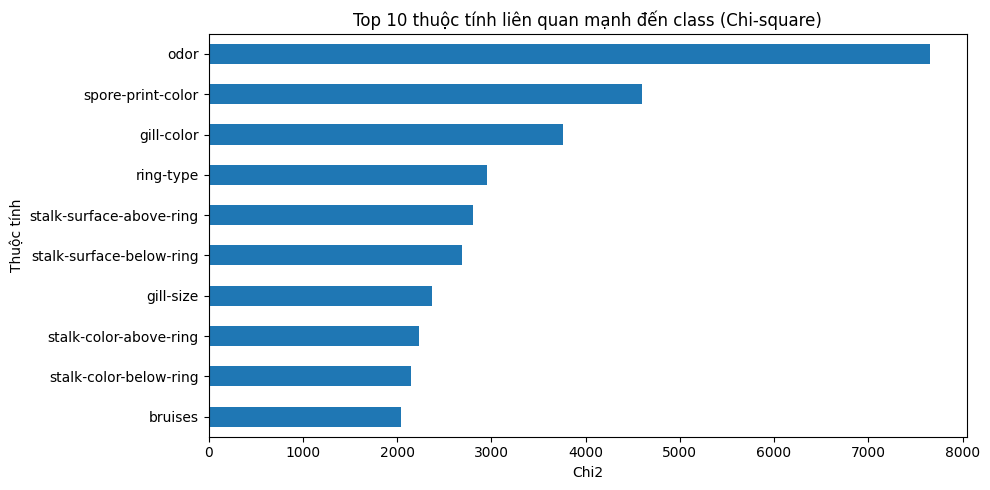

In [ ]:
## Tính Chi-square cho từng thuộc tính
from scipy.stats import chi2_contingency
from matplotlib import pyplot as plt
print("=" * 60)
print("PHÂN TÍCH MỐI LIÊN HỆ GIỮA CÁC THUỘC TÍNH VÀ CLASS")
print("=" * 60)

chi2_results = {}

for col in df.columns:

    # Không tính class với chính nó
    if col != 'class':

        contingency = pd.crosstab(
            df[col],
            df['class']
        )

        chi2, p, dof, expected = chi2_contingency(contingency)

        chi2_results[col] = {
            'Chi2': chi2,
            'p-value': p
        }

chi2_df = pd.DataFrame.from_dict(
    chi2_results,
    orient='index'
)

chi2_df = chi2_df.sort_values(
    'Chi2',
    ascending=False
)

print("\nTop 10 thuộc tính liên quan mạnh nhất đến class:")
display(chi2_df.head(10))

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

chi2_df.head(10)['Chi2'].plot(
    kind='barh'
)

plt.title(
    'Top 10 thuộc tính liên quan mạnh đến class (Chi-square)',
    fontsize=12
)

plt.xlabel('Chi2')
plt.ylabel('Thuộc tính')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

PHÂN TÍCH CHI TIẾT THUỘC TÍNH 'ODOR' (MÙI)

Bảng chéo odor vs class:


class,e,p
odor,,
a,400,0
c,0,192
f,0,2160
l,400,0
m,0,36
n,3408,120
p,0,256
s,0,576
y,0,576


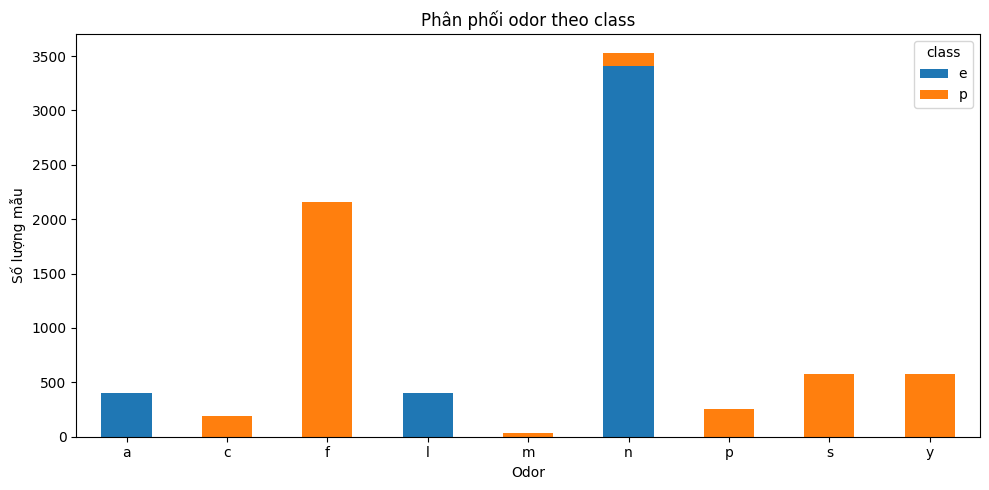


-> Nhận xét:
   Bảng chéo trên cho thấy mối quan hệ giữa thuộc tính odor
   và hai lớp edible (e) / poisonous (p).
   Không kết luận cứng trước khi quan sát kết quả thực tế.


In [ ]:
# Phân tích thuộc tính 'odor'

print("=" * 60)
print("PHÂN TÍCH CHI TIẾT THUỘC TÍNH 'ODOR' (MÙI)")
print("=" * 60)

odor_table = pd.crosstab(
    df['odor'],
    df['class']
)

print("\nBảng chéo odor vs class:")
display(odor_table)

# Vẽ biểu đồ
odor_table.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title(
    'Phân phối odor theo class',
    fontsize=12
)

plt.xlabel('Odor')
plt.ylabel('Số lượng mẫu')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("\n-> Nhận xét:")
print("   Bảng chéo trên cho thấy mối quan hệ giữa thuộc tính odor")
print("   và hai lớp edible (e) / poisonous (p).")
print("   Không kết luận cứng trước khi quan sát kết quả thực tế.")

In [ ]:
#  Tạo danh sách giao dịch

print("=" * 60)
print("TẠO CẤU TRÚC TRANSACTION")
print("=" * 60)

transactions = []

for idx, row in df.iterrows():

    transaction = []

    for col in df.columns:

        item = f"{col}={row[col]}"

        transaction.append(item)

    transactions.append(transaction)

print(f"Số giao dịch: {len(transactions)}")

print(
    f"Số item trong mỗi giao dịch: "
    f"{len(transactions[0])}"
)

print("\nVí dụ giao dịch đầu tiên:")
print(transactions[0])

print("\nVí dụ giao dịch thứ hai:")
print(transactions[1])

# Lưu lại transactions
import pickle

with open(
    'transactions_list.pkl',
    'wb'
) as f:

    pickle.dump(
        transactions,
        f
    )

print(
    "\nĐã lưu danh sách giao dịch vào "
    "transactions_list.pkl"
)

TẠO CẤU TRÚC TRANSACTION
Số giao dịch: 8124
Số item trong mỗi giao dịch: 22

Ví dụ giao dịch đầu tiên:
['class=p', 'cap-shape=x', 'cap-surface=s', 'cap-color=n', 'bruises=t', 'odor=p', 'gill-attachment=f', 'gill-spacing=c', 'gill-size=n', 'gill-color=k', 'stalk-shape=e', 'stalk-root=e', 'stalk-surface-above-ring=s', 'stalk-surface-below-ring=s', 'stalk-color-above-ring=w', 'stalk-color-below-ring=w', 'veil-color=w', 'ring-number=o', 'ring-type=p', 'spore-print-color=k', 'population=s', 'habitat=u']

Ví dụ giao dịch thứ hai:
['class=e', 'cap-shape=x', 'cap-surface=s', 'cap-color=y', 'bruises=t', 'odor=a', 'gill-attachment=f', 'gill-spacing=c', 'gill-size=b', 'gill-color=k', 'stalk-shape=e', 'stalk-root=c', 'stalk-surface-above-ring=s', 'stalk-surface-below-ring=s', 'stalk-color-above-ring=w', 'stalk-color-below-ring=w', 'veil-color=w', 'ring-number=o', 'ring-type=p', 'spore-print-color=n', 'population=n', 'habitat=g']

Đã lưu danh sách giao dịch vào transactions_list.pkl


In [ ]:
# Chuyển đổi Transaction sang ma trận One-Hot

from mlxtend.preprocessing import TransactionEncoder

print("=" * 60)
print("CHUYỂN ĐỔI SANG MA TRẬN ONE-HOT")
print("=" * 60)

te = TransactionEncoder()

te_ary = te.fit(
    transactions
).transform(
    transactions
)

df_trans = pd.DataFrame(
    te_ary,
    columns=te.columns_
)

print(
    f"Kích thước ma trận transaction: "
    f"{df_trans.shape}"
)

print(
    f"   - Số giao dịch (dòng): "
    f"{df_trans.shape[0]}"
)

print(
    f"   - Số item (cột): "
    f"{df_trans.shape[1]}"
)

print("\n5 dòng đầu tiên:")
display(
    df_trans.head()
)

# Thống kê mật độ
total_cells = (
    df_trans.shape[0] *
    df_trans.shape[1]
)

ones = df_trans.values.sum()

density = (
    ones /
    total_cells *
    100
)

print("\nThống kê mật độ ma trận:")
print(f"   - Tổng số ô: {total_cells:,}")
print(f"   - Số ô = 1: {ones:,}")
print(f"   - Mật độ: {density:.2f}%")

CHUYỂN ĐỔI SANG MA TRẬN ONE-HOT
Kích thước ma trận transaction: (8124, 118)
   - Số giao dịch (dòng): 8124
   - Số item (cột): 118

5 dòng đầu tiên:


,bruises=f,bruises=t,cap-color=b,cap-color=c,cap-color=e,cap-color=g,cap-color=n,cap-color=p,cap-color=r,cap-color=u,...,stalk-surface-above-ring=s,stalk-surface-above-ring=y,stalk-surface-below-ring=f,stalk-surface-below-ring=k,stalk-surface-below-ring=s,stalk-surface-below-ring=y,veil-color=n,veil-color=o,veil-color=w,veil-color=y
0,False,True,False,False,False,False,True,False,False,False,...,True,False,False,False,True,False,False,False,True,False
1,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
2,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
3,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
4,True,False,False,False,False,True,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False



Thống kê mật độ ma trận:
   - Tổng số ô: 958,632
   - Số ô = 1: 178,728
   - Mật độ: 18.64%


In [ ]:
# Lưu dữ liệu transaction và báo cáo EDA

import os
import pandas as pd

# Tính lại phân phối class để Cell 9 chạy độc lập
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

# 1. Lưu transaction
transactions_path = 'transactions.csv'

df_trans.to_csv(
    transactions_path,
    index=False
)

print(f"Đã lưu file: {transactions_path}")


# 2. Lưu báo cáo EDA
report_path = 'Mushroom_EDA_Report.xlsx'

with pd.ExcelWriter(
    report_path,
    engine='openpyxl'
) as writer:

    # Sheet 1: Chi-square
    chi2_df.to_excel(
        writer,
        sheet_name='Chi-square',
        index=False
    )

    # Sheet 2: Odor vs Class
    odor_table.to_excel(
        writer,
        sheet_name='Odor_vs_Class'
    )

    # Sheet 3: Phân phối lớp
    pd.DataFrame({
        'Lớp': [
            'e (edible)',
            'p (poisonous)'
        ],

        'Số mẫu': [
            class_counts.get('e', 0),
            class_counts.get('p', 0)
        ],

        'Tỷ lệ (%)': [
            round(class_pct.get('e', 0), 2),
            round(class_pct.get('p', 0), 2)
        ]

    }).to_excel(
        writer,
        sheet_name='Phân_phối_lớp',
        index=False
    )


print(f"Đã lưu file báo cáo: {report_path}")

Đã lưu file: transactions.csv
Đã lưu file báo cáo: Mushroom_EDA_Report.xlsx


In [ ]:
# 3. Kiểm tra file
print("\nCác file đã tạo:")

for f in os.listdir('.'):

    if f.endswith(
        ('.csv', '.xlsx', '.pkl')
    ):

        size = os.path.getsize(f) / 1024

        print(
            f"   - {f} "
            f"({size:.2f} KB)"
        )


Các file đã tạo:
   - transactions_list.pkl (3031.08 KB)
   - Mushroom_EDA_Report.xlsx (6.65 KB)
   - mushrooms.csv (365.24 KB)
   - transactions.csv (5444.24 KB)
   - Mushroom_Preprocessed_Dataset_Cleaned.xlsx (560.32 KB)
